# Particle count in a Wasserstein gradient flow of squared MMD / energy distance

This notebook generates `fig:gradflow-mmd-particle-count`.  The target distribution $\beta$ is a smooth two-component Gaussian mixture, represented only through its true density contours.  The displayed particles are not independent samples from $\beta$; they follow the deterministic Wasserstein gradient flow of the squared MMD, here the squared energy distance induced by the conditionally positive kernel

$$
k(x,y)=-\|x-y\|.
$$

For a signed measure of zero total mass, this kernel defines

$$
\mathcal E(\alpha)=\|\alpha-\beta\|_k^2
=\iint k(x,y)\,d(\alpha-\beta)(x)d(\alpha-\beta)(y),
$$

which is the usual squared energy distance.  For an empirical measure, the Wasserstein gradient flow gives a particle ODE with a repulsive self-interaction and an attraction toward the continuous teacher kernel mean.  The continuum minimizer is $\beta$, while finite particle systems approximate it only through a kernelized quadrature.  The three panels compare $n=10$, $n=50$, and $n=300$ particles under the same flow, starting from a compact isotropic Gaussian placed farther from the target modes and integrated until the final cloud is visually stable.


n=010: terminal speed mean/max 1.118e-03/3.063e-03; last 10% displacement mean/max 3.979e-03/1.097e-02
n=050: terminal speed mean/max 1.259e-03/1.137e-02; last 10% displacement mean/max 4.497e-03/4.226e-02
n=300: terminal speed mean/max 5.264e-04/1.245e-02; last 10% displacement mean/max 1.889e-03/4.273e-02


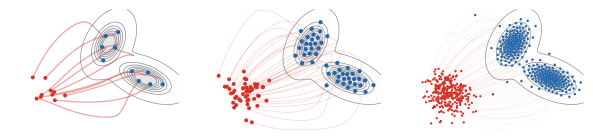

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.interpolate import RegularGridInterpolator

ROOT = Path.cwd().resolve().parents[0]
if str(ROOT / "notebooks-figures") not in sys.path:
    sys.path.append(str(ROOT / "notebooks-figures"))
from figure_style import setup_matplotlib, figure_dir, save_pdf, remove_axes, RED, BLUE, interp_color

setup_matplotlib()
rng = np.random.default_rng(20260616)
name = "gradflow-mmd-particle-count"
out_dir = figure_dir(name)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(exist_ok=True)

# Smooth teacher distribution beta, shown only through true density contours.
w = np.array([0.48, 0.52])
means = np.array([[0.24, 0.40], [0.86, -0.18]])
Sigmas = np.array([
    [[0.14**2, 0.010], [0.010, 0.18**2]],
    [[0.21**2, -0.014], [-0.014, 0.13**2]],
])
invS = np.linalg.inv(Sigmas)
dets = np.linalg.det(Sigmas)

xlim = (-1.42, 1.42)
ylim = (-1.05, 0.98)
ng = 240
grid_x = np.linspace(*xlim, ng)
grid_y = np.linspace(*ylim, ng)
XX, YY = np.meshgrid(grid_x, grid_y)
GRID = np.stack([XX, YY], axis=-1)

def component_densities(X):
    vals = []
    for wi, m, S_inv, det in zip(w, means, invS, dets):
        d = X - m
        q = np.einsum("...i,ij,...j->...", d, S_inv, d)
        vals.append(wi * np.exp(-0.5 * q) / (2 * np.pi * np.sqrt(det)))
    return np.stack(vals, axis=-1)

def target_density(X):
    return component_densities(X).sum(axis=-1)

Z = target_density(GRID)

# Squared-MMD / energy-distance Wasserstein gradient flow for k(x,y)=-||x-y||.
# For E(alpha)=||alpha-beta||_k^2, delta E / delta alpha = 2(k*alpha-k*beta),
# hence xdot_i = -2(grad k*alpha_n(x_i)-grad k*beta(x_i)).
# The singular force is only softly regularized for numerical stability.
force_softening = 0.018
quad_grid_size = 95
force_grid_size = 150

quad_x = np.linspace(*xlim, quad_grid_size)
quad_y = np.linspace(*ylim, quad_grid_size)
QX, QY = np.meshgrid(quad_x, quad_y)
quad_points = np.column_stack([QX.ravel(), QY.ravel()])
quad_weights = target_density(np.stack([QX, QY], axis=-1)).ravel()
quad_weights = quad_weights / max(float(quad_weights.sum()), 1e-15)

force_x = np.linspace(*xlim, force_grid_size)
force_y = np.linspace(*ylim, force_grid_size)
FX, FY = np.meshgrid(force_x, force_y)
force_points = np.column_stack([FX.ravel(), FY.ravel()])

target_field = np.zeros_like(force_points)
batch_size = 512
for start in range(0, len(force_points), batch_size):
    stop = min(start + batch_size, len(force_points))
    D = force_points[start:stop, None, :] - quad_points[None, :, :]
    R = np.sqrt(np.sum(D * D, axis=2) + force_softening**2)
    target_field[start:stop] = -np.sum(
        quad_weights[None, :, None] * D / R[:, :, None],
        axis=1,
    )

target_field = target_field.reshape(force_grid_size, force_grid_size, 2)
target_grad_x = RegularGridInterpolator(
    (force_y, force_x), target_field[:, :, 0], bounds_error=False, fill_value=None
)
target_grad_y = RegularGridInterpolator(
    (force_y, force_x), target_field[:, :, 1], bounds_error=False, fill_value=None
)

def target_kernel_grad(X):
    pts = np.column_stack([X[:, 1], X[:, 0]])
    return np.column_stack([target_grad_x(pts), target_grad_y(pts)])

def empirical_kernel_grad(X):
    D = X[:, None, :] - X[None, :, :]
    R = np.sqrt(np.sum(D * D, axis=2) + force_softening**2)
    return -np.mean(D / R[:, :, None], axis=1)

def mmd_velocity(X):
    V = 2.0 * (target_kernel_grad(X) - empirical_kernel_grad(X))
    speed = np.linalg.norm(V, axis=1, keepdims=True)
    return V * np.minimum(1.0, 0.40 / np.maximum(speed, 1e-12))


T = 32.0
steps = 5120
dt = T / steps
record_every = 43
counts = [10, 50, 300]
init_mean = np.array([-0.86, -0.43])
init_std = 0.18

trajectories = {}
stability = {}
for n in counts:
    X = init_mean + init_std * rng.normal(size=(n, 2))
    frames = [X.copy()]
    late_reference = None
    for k in range(steps):
        if k == int(0.90 * steps):
            late_reference = X.copy()
        X = X + dt * mmd_velocity(X)
        # Keep the numerical toy problem inside the displayed compact window.
        X[:, 0] = np.clip(X[:, 0], xlim[0] + 0.01, xlim[1] - 0.01)
        X[:, 1] = np.clip(X[:, 1], ylim[0] + 0.01, ylim[1] - 0.01)
        if (k + 1) % record_every == 0 or k == steps - 1:
            frames.append(X.copy())
    trajectories[n] = np.asarray(frames)
    final_speed = np.linalg.norm(mmd_velocity(X), axis=1)
    late_displacement = np.linalg.norm(X - late_reference, axis=1)
    stability[n] = {
        "mean_speed": float(final_speed.mean()),
        "max_speed": float(final_speed.max()),
        "mean_late_displacement": float(late_displacement.mean()),
        "max_late_displacement": float(late_displacement.max()),
    }

for n, stats in stability.items():
    print(
        f"n={n:03d}: terminal speed mean/max "
        f"{stats['mean_speed']:.3e}/{stats['max_speed']:.3e}; "
        f"last 10% displacement mean/max "
        f"{stats['mean_late_displacement']:.3e}/{stats['max_late_displacement']:.3e}"
    )

def draw_panel(ax, traj, n):
    levels = np.linspace(np.quantile(Z, 0.74), np.quantile(Z, 0.982), 7)
    ax.contour(XX, YY, Z, levels=levels, colors="#3d3d3d", linewidths=0.48, alpha=0.58)
    ax.imshow(
        np.clip(Z, 0, np.quantile(Z, 0.985)),
        extent=[*xlim, *ylim],
        origin="lower",
        cmap="Greys",
        alpha=0.10,
    )

    nT, nP, _ = traj.shape
    display_count = min(nP, {10: 10, 50: 34, 300: 82}[n])
    idx = np.linspace(0, nP - 1, display_count, dtype=int)
    line_alpha = {10: 0.42, 50: 0.18, 300: 0.070}[n]
    line_width = {10: 0.92, 50: 0.54, 300: 0.28}[n]
    segs, cols = [], []
    for i in idx:
        pts = traj[:, i, :]
        segs.extend(np.stack([pts[:-1], pts[1:]], axis=1))
        cols.extend([(*interp_color(k / max(nT - 2, 1)), line_alpha) for k in range(nT - 1)])
    lc = LineCollection(segs, colors=cols, linewidths=line_width, zorder=2)
    ax.add_collection(lc)

    ax.scatter(traj[0, :, 0], traj[0, :, 1], s=8 if n <= 50 else 2.7, color=RED, edgecolor="none", zorder=4)
    ax.scatter(traj[-1, :, 0], traj[-1, :, 1], s=9 if n <= 50 else 3.1, color=BLUE, edgecolor="none", zorder=5)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)

for n in counts:
    fig, ax = plt.subplots(figsize=(2.45, 2.05))
    draw_panel(ax, trajectories[n], n)
    save_pdf(fig, out_dir / f"n-{n:03d}.pdf")
    plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.25))
for ax, n in zip(axes, counts):
    draw_panel(ax, trajectories[n], n)
fig.savefig(thumb_dir / f"{name}.png", dpi=180, bbox_inches="tight", pad_inches=0.025)
plt.show()
